# MNIST Fully Connected Network
This notebook shows how to train a fully connected neural network on the MNIST dataset using PyTorch in a Colab-style workflow. It includes dataset loading, model training with TensorBoard, evaluation with a confusion matrix, and a plot of the 64 worst predictions.

In [2]:
# Colab-style imports and TensorBoard setup
import os
import datetime
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix, classification_report

print("PyTorch version:", torch.__version__)

PyTorch version: 2.11.0+cpu


## 1. Load MNIST dataset
We load MNIST from `torchvision.datasets`, normalize the images, and inspect the training data shapes and labels.

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

print("Train dataset size:", len(train_dataset))
print("Test dataset size:", len(test_dataset))
print("Example labels:", [train_dataset[i][1] for i in range(10)])

Train dataset size: 60000
Test dataset size: 10000
Example labels: [5, 0, 4, 1, 9, 2, 1, 3, 1, 4]


## 2. View samples and labels
Visualize the first few MNIST images and check their corresponding labels.

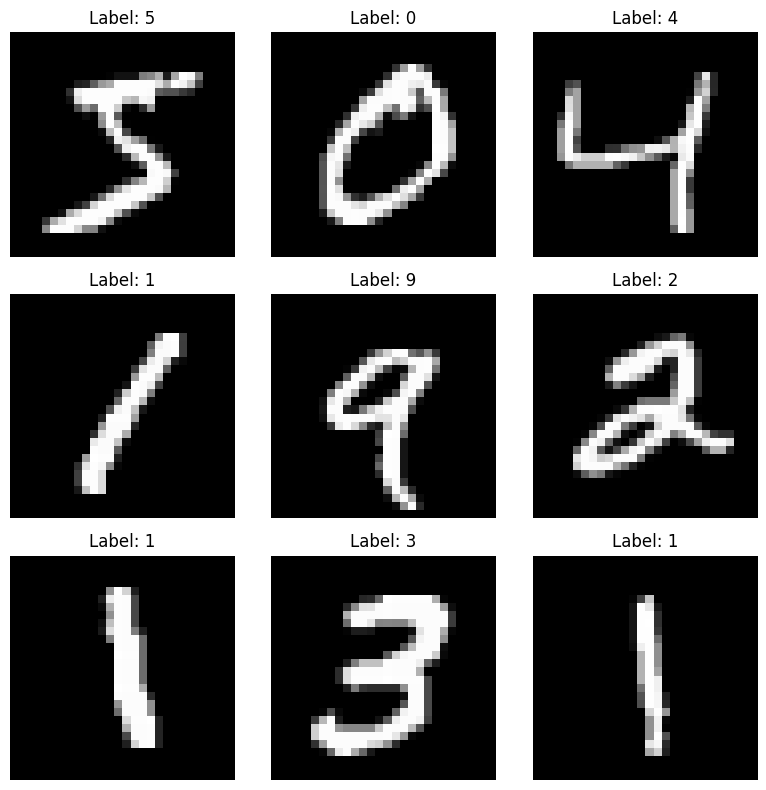

In [4]:
fig, axes = plt.subplots(3, 3, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]
    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 3. Prepare the dataloader with a batch size
Set the batch size and create `DataLoader` pipelines for training and evaluation.

In [5]:
batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False)

print("Batch size:", batch_size)
for images, labels in train_loader:
    print("Batch shape:", images.shape, labels.shape)
    break

Batch size: 128
Batch shape: torch.Size([128, 1, 28, 28]) torch.Size([128])


## 4. Define the fully connected model
Build a simple fully connected network with two hidden layers and a softmax output.

In [6]:
class FullyConnectedNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28 * 28, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = FullyConnectedNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(model)
print("Using device:", device)

FullyConnectedNN(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=10, bias=True)
)
Using device: cpu


## 5. Train with TensorBoard monitoring
Train the model while logging metrics into TensorBoard so students can inspect the training process.

In [7]:
log_dir = os.path.join("logs", "mnist_fc_" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
writer = SummaryWriter(log_dir=log_dir)

epochs = 5

for epoch in range(1, epochs + 1):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    model.eval()
    test_loss = 0.0
    test_correct = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            test_correct += (preds == labels).sum().item()

    test_loss /= len(test_dataset)
    test_acc = test_correct / len(test_dataset)

    print(f"Epoch {epoch}/{epochs} - train_loss: {train_loss:.4f}, train_acc: {train_acc:.4f}, test_loss: {test_loss:.4f}, test_acc: {test_acc:.4f}")
    writer.add_scalar("Loss/train", train_loss, epoch)
    writer.add_scalar("Accuracy/train", train_acc, epoch)
    writer.add_scalar("Loss/test", test_loss, epoch)
    writer.add_scalar("Accuracy/test", test_acc, epoch)

writer.close()
print("TensorBoard logs saved to:", log_dir)

Epoch 1/5 - train_loss: 0.2306, train_acc: 0.9311, test_loss: 0.0997, test_acc: 0.9689
Epoch 2/5 - train_loss: 0.0871, train_acc: 0.9732, test_loss: 0.0731, test_acc: 0.9768
Epoch 3/5 - train_loss: 0.0566, train_acc: 0.9818, test_loss: 0.0753, test_acc: 0.9774
Epoch 4/5 - train_loss: 0.0437, train_acc: 0.9856, test_loss: 0.0746, test_acc: 0.9780
Epoch 5/5 - train_loss: 0.0319, train_acc: 0.9892, test_loss: 0.0621, test_acc: 0.9809
TensorBoard logs saved to: logs\mnist_fc_20260415-154944


In [8]:
# Launch TensorBoard in Colab-style notebooks
%load_ext tensorboard
%tensorboard --logdir {log_dir}

## 6. Evaluate with a confusion matrix
Evaluate the trained model on the test set and plot a confusion matrix to see which digits are most often confused.

Test accuracy: 0.9809
Classification report:
              precision    recall  f1-score   support

           0     0.9868    0.9908    0.9888       980
           1     0.9930    0.9938    0.9934      1135
           2     0.9892    0.9797    0.9844      1032
           3     0.9632    0.9861    0.9746      1010
           4     0.9777    0.9817    0.9797       982
           5     0.9930    0.9596    0.9761       892
           6     0.9884    0.9770    0.9827       958
           7     0.9769    0.9854    0.9811      1028
           8     0.9676    0.9805    0.9740       974
           9     0.9741    0.9703    0.9722      1009

    accuracy                         0.9809     10000
   macro avg     0.9810    0.9805    0.9807     10000
weighted avg     0.9810    0.9809    0.9809     10000



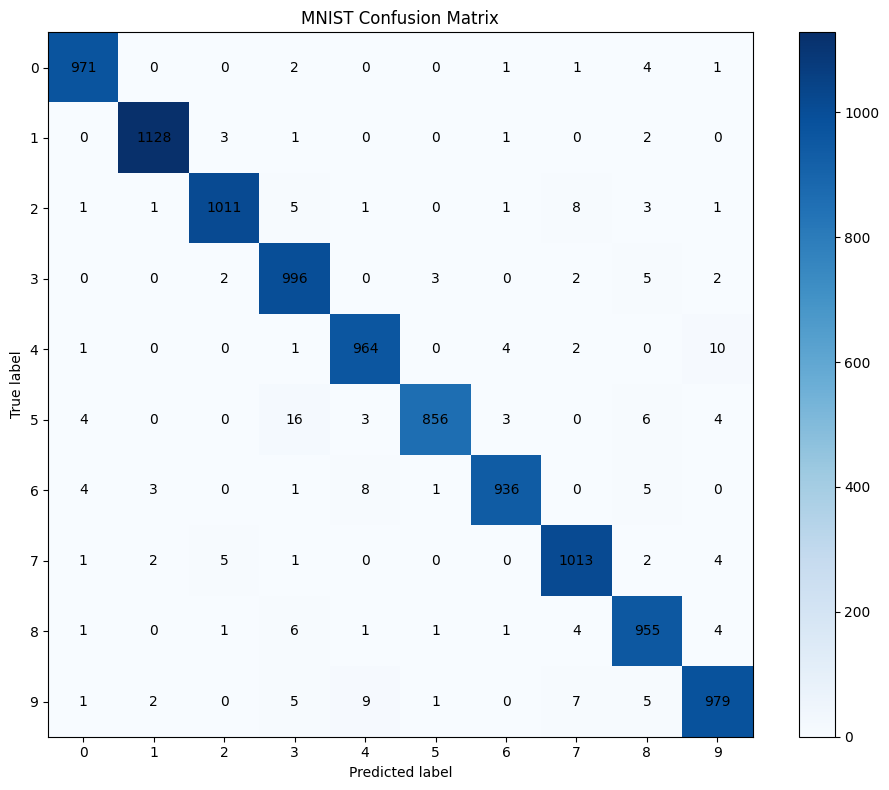

In [9]:
model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = F.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.numpy())
        all_probs.append(probs.cpu().numpy())

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)
all_probs = np.concatenate(all_probs)

print(f"Test accuracy: {np.mean(all_preds == all_labels):.4f}")
print("Classification report:")
print(classification_report(all_labels, all_preds, digits=4))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("MNIST Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.colorbar()

ticks = np.arange(10)
plt.xticks(ticks)
plt.yticks(ticks)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, f"{cm[i, j]}", ha="center", va="center", color="black")
plt.tight_layout()
plt.show()

## 7. Plot the 64 worst predictions
Show the 64 most confidently wrong predictions in an 8x8 grid to inspect the hardest model errors.

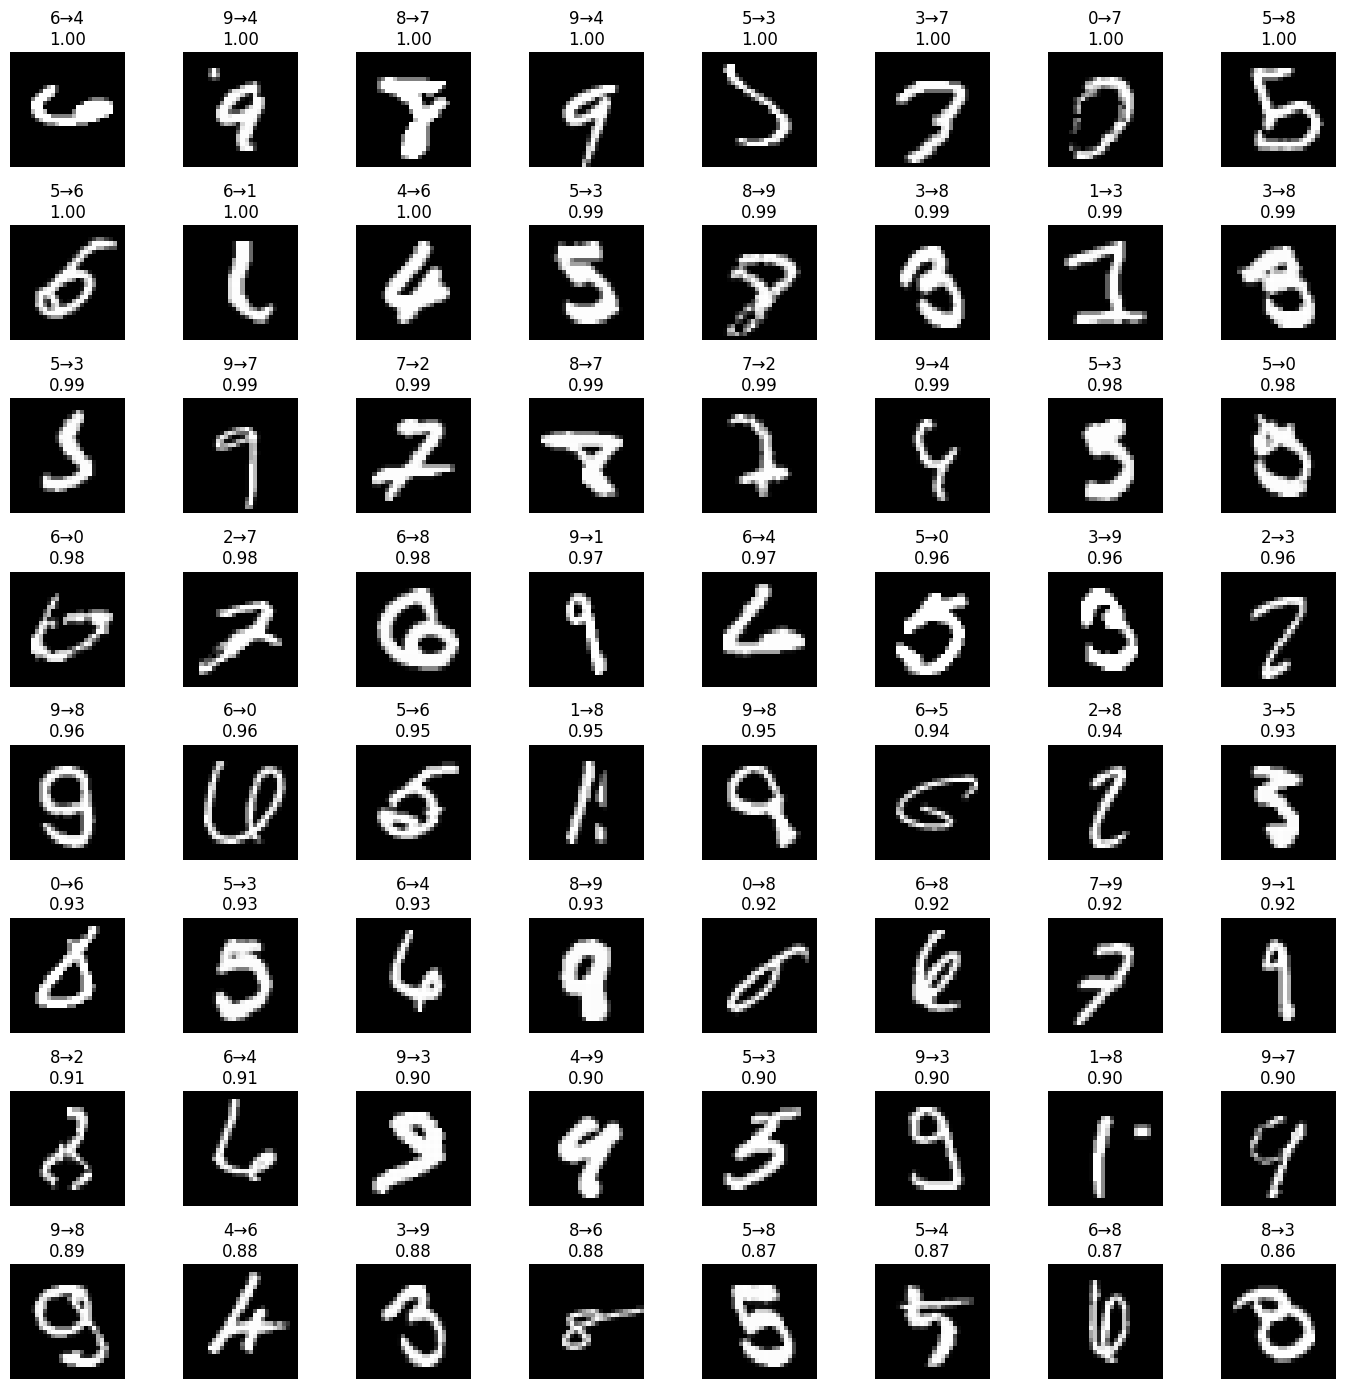

In [10]:
wrong_indices = np.where(all_preds != all_labels)[0]
if wrong_indices.size == 0:
    raise ValueError("No incorrect predictions found.")

wrong_confidence = np.max(all_probs[wrong_indices], axis=1)
worst_order = np.argsort(-wrong_confidence)
worst_indices = wrong_indices[worst_order][:64]

rows, cols = 8, 8
fig, axes = plt.subplots(rows, cols, figsize=(14, 14))
for ax, idx in zip(axes.flat, worst_indices):
    image, label = test_dataset[idx]
    ax.imshow(image.squeeze(), cmap="gray")
    pred_label = all_preds[idx]
    true_label = all_labels[idx]
    score = all_probs[idx, pred_label]
    ax.set_title(f"{true_label}→{pred_label}\n{score:.2f}")
    ax.axis("off")

plt.tight_layout()
plt.show()